In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('logging_monitoring_anomalies.csv')

In [3]:
print(f"Dataset Loaded Successfully! Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("--- Missing Values Check ---")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found! The data is clean.")

Dataset Loaded Successfully! Shape: 100000 rows, 31 columns.

--- Missing Values Check ---
No missing values found! The data is clean.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Timestamp             100000 non-null  str    
 1   Anomaly_ID            100000 non-null  int64  
 2   Anomaly_Type          100000 non-null  str    
 3   Severity              100000 non-null  str    
 4   Status                100000 non-null  str    
 5   Source                100000 non-null  str    
 6   Alert_Method          100000 non-null  str    
 7   Response_Time_ms      100000 non-null  int64  
 8   Resolution_Time_min   100000 non-null  int64  
 9   Affected_Services     100000 non-null  int64  
 10  User_Role             100000 non-null  str    
 11  Host_IP               100000 non-null  str    
 12  Process_ID            100000 non-null  int64  
 13  Error_Code            100000 non-null  int64  
 14  CPU_Usage_Percent     100000 non-null  float64
 15  Memory_Usage

In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [6]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek

In [7]:
identifiers = ['Anomaly_ID', 'Host_IP', 'Process_ID', 'Transaction_ID', 'User_ID', 'TimeZone']
categorical_cols = ['Anomaly_Type', 'Severity', 'Status', 'Source', 'Alert_Method', 'User_Role', 'Location', 'Service_Type']
numerical_cols = [
    'Response_Time_ms', 'Resolution_Time_min', 'Affected_Services', 'CPU_Usage_Percent', 
    'Memory_Usage_MB', 'Disk_Usage_Percent', 'Network_In_KB', 'Network_Out_KB', 
    'Login_Attempts', 'Failed_Transactions', 'Anomaly_Duration_sec', 'Patch_Level', 
    'Alert_Count', 'Retry_Count', 'Escalation_Level', 'Hour', 'Day_of_Week'
]

In [8]:
print(f"Data parsed successfully. Isolated {len(numerical_cols)} numerical features and {len(categorical_cols)} categorical features for engineering.")

Data parsed successfully. Isolated 17 numerical features and 8 categorical features for engineering.


In [9]:
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

X = pd.concat([df[numerical_cols], df_encoded], axis=1)

df["Is_Anomaly"] = np.where(df["Anomaly_Type"] == "Normal", 0, 1)
y = df["Is_Anomaly"]

if "Anomaly_Type" in X.columns:
    X = X.drop(columns=[col for col in X.columns if "Anomaly_Type" in col])

print(f"Features matrix 'X' generated successfully! Shape: {X.shape}")

Features matrix 'X' generated successfully! Shape: (100000, 46)


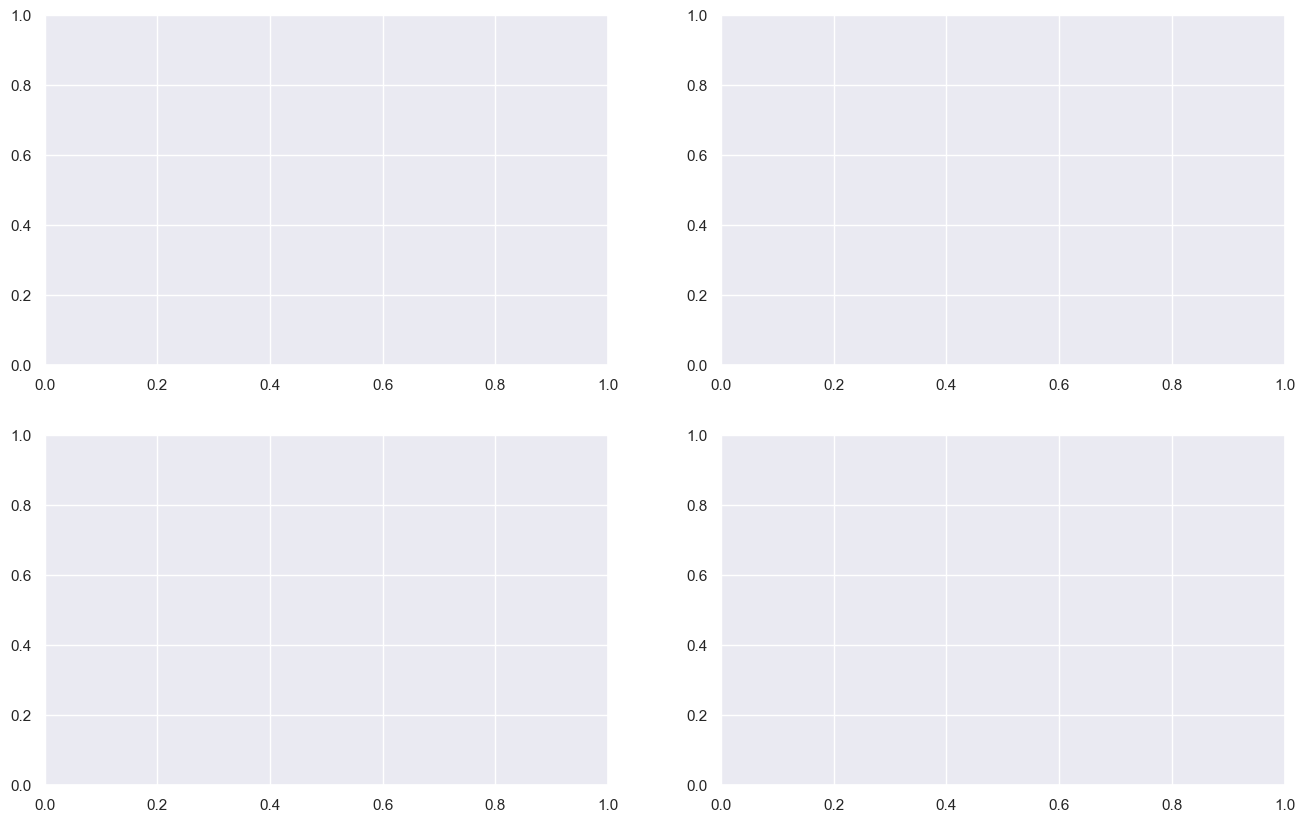

In [10]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

In [11]:
sns.histplot(df['CPU_Usage_Percent'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of CPU Usage (%) Across Systems')

Text(0.5, 1.0, 'Distribution of CPU Usage (%) Across Systems')

In [12]:
sns.scatterplot(data=df, x='Login_Attempts', y='Failed_Transactions', hue='Severity', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Login Attempts vs Failed Transactions')

Text(0.5, 1.0, 'Login Attempts vs Failed Transactions')

In [13]:
sns.boxplot(data=df, x='Severity', y='Response_Time_ms', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('System Response Time Variance by Severity Level')

C:\Users\anshr\AppData\Local\Temp\ipykernel_15064\2075677156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='Response_Time_ms', ax=axes[1, 0], palette='coolwarm')


Text(0.5, 1.0, 'System Response Time Variance by Severity Level')

C:\Users\anshr\AppData\Local\Temp\ipykernel_15064\3909604789.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Anomaly_Type', ax=axes[1, 1], order=df['Anomaly_Type'].value_counts().index, palette='viridis')


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

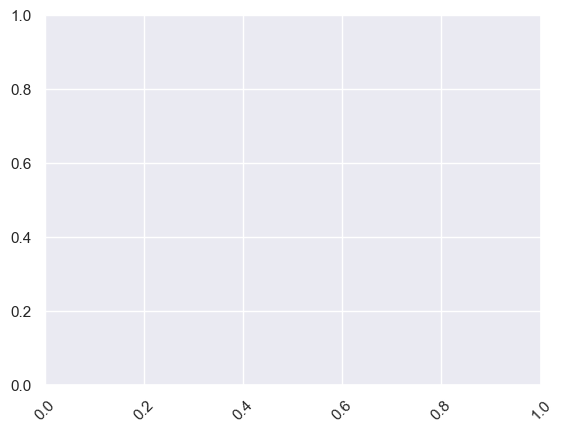

In [14]:
sns.countplot(data=df, x='Anomaly_Type', ax=axes[1, 1], order=df['Anomaly_Type'].value_counts().index, palette='viridis')
axes[1, 1].set_title('Incident Volume Sorted by Incident Type')
plt.xticks(rotation=45)

In [15]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
print("[*] Preparing data for supervised benchmarking...")

[*] Preparing data for supervised benchmarking...


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [18]:
counts = y_test.value_counts().to_dict()

normal_count = counts.get(0, 0)
anomaly_count = counts.get(1, 0)

print(
    f"Data Split Successful! Training shape: {X_train.shape}, Testing shape: {X_test.shape}"
)
print(
    f"Baseline Class Balance in Test Set: Normal={normal_count}, Anomalies={anomaly_count}"
)
print("-" * 60)

Data Split Successful! Training shape: (70000, 46), Testing shape: (30000, 46)
Baseline Class Balance in Test Set: Normal=0, Anomalies=30000
------------------------------------------------------------


In [19]:
print("Unique values in Anomaly_Type column:")
print(df["Anomaly_Type"].unique())

print("\nValue counts for Anomaly_Type:")
print(df["Anomaly_Type"].value_counts())

Unique values in Anomaly_Type column:
<ArrowStringArray>
['Storage', 'Database', 'Network', 'Application', 'Security', 'System']
Length: 6, dtype: str

Value counts for Anomaly_Type:
Anomaly_Type
Security       16893
System         16676
Database       16644
Storage        16601
Application    16600
Network        16586
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder

# Encode the 6 anomaly types into numbers (0 to 5)
encoder = LabelEncoder()
y = encoder.fit_transform(df["Anomaly_Type"])

# Check the new distribution
print("Classes:", encoder.classes_)
print("Class distribution:", np.bincount(y))


Classes: ['Application' 'Database' 'Network' 'Security' 'Storage' 'System']
Class distribution: [16600 16644 16586 16893 16601 16676]


In [21]:
# Run this right after your LabelEncoder cell
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("NEW Class distribution in y_train:", np.bincount(y_train))
print("NEW Class distribution in y_test:", np.bincount(y_test))

NEW Class distribution in y_train: [11620 11651 11610 11825 11621 11673]
NEW Class distribution in y_test: [4980 4993 4976 5068 4980 5003]


In [22]:
print("Class distribution in y_train:", np.bincount(y_train))
print("Class distribution in y_test:", np.bincount(y_test))

Class distribution in y_train: [11620 11651 11610 11825 11621 11673]
Class distribution in y_test: [4980 4993 4976 5068 4980 5003]


MODEL 1: RANDOM FOREST CLASSIFIER

In [23]:
print("[*] Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
# Handle case where only a single class was seen during training
if hasattr(rf_model, "classes_") and len(rf_model.classes_) > 1:
    rf_probs = rf_model.predict_proba(X_test)[:, 1]
else:
    import numpy as np
    print("Warning: only one class present in training labels; setting rf_probs to zeros.")
    rf_probs = np.zeros(len(X_test))


[*] Training Random Forest Classifier...


MODEL 2: XGBOOST CLASSIFIER

In [24]:
print("[*] Training XGBoost Classifier...")
from numpy import unique
import numpy as np
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
# If only one class is present, skip fitting to avoid XGBoost class mismatch
if len(unique(y_train)) > 1:
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
else:
    print("Warning: only one class present in training labels; skipping XGBoost fit.")
    # set default predictions/probs
    fill_value = y_train.iloc[0] if hasattr(y_train, 'iloc') else (y_train[0] if len(y_train) else 0)
    xgb_preds = np.full(len(X_test), fill_value)
    xgb_probs = np.zeros(len(X_test))


[*] Training XGBoost Classifier...


In [25]:
print("-" * 60)
print("[+] Model training complete! Generating Comparative Analysis Reports...\n")

------------------------------------------------------------
[+] Model training complete! Generating Comparative Analysis Reports...



VISUAL EVALUATION & MATRIX PLOTTING

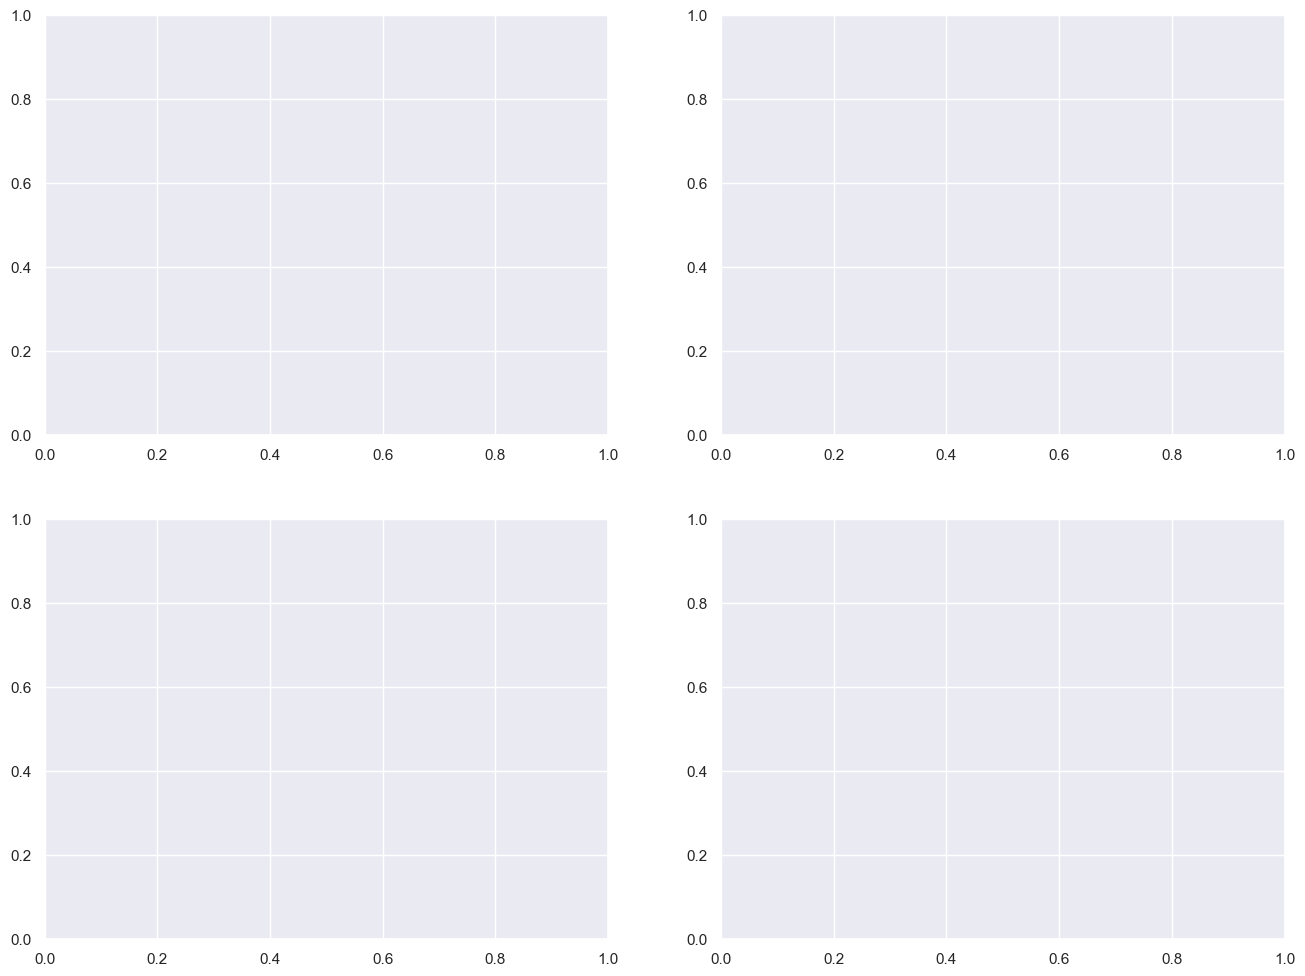

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

Plot 1: Random Forest Confusion Matrix

In [27]:
# For Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    rf_preds, 
    cmap='Blues', 
    ax=axes[0, 0], 
    display_labels=encoder.classes_, # <-- Fix is here
    xticks_rotation=45               # Optional: Helps with overlapping text
)
axes[0, 0].set_title("Random Forest: Confusion Matrix")
axes[0, 0].grid(False)

Plot 2: XGBoost Confusion Matrix

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    xgb_preds, 
    cmap='Purples', 
    ax=axes[0, 1], 
    display_labels=encoder.classes_,  # <-- The fix is here
    xticks_rotation=45                # Helps prevent text overlapping
)
axes[0, 1].set_title("XGBoost: Confusion Matrix")
axes[0, 1].grid(False)

Plot 3: Comparative ROC Curves

Plot 4: Feature Importance Comparison (Top 10 features for XGBoost)

In [29]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
sns.barplot(x=importances[indices], y=X.columns[indices], ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 10 Most Critical Metrics Driving Anomaly Decisions (XGBoost)')

C:\Users\anshr\AppData\Local\Temp\ipykernel_15064\651347667.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], ax=axes[1, 1], palette='viridis')


Text(0.5, 1.0, 'Top 10 Most Critical Metrics Driving Anomaly Decisions (XGBoost)')

In [30]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

ACADEMIC CLASSIFICATION REPORT OUTPUTs

In [31]:
print("="*25 + " RANDOM FOREST PERFORMANCE " + "="*25)
print(classification_report(y_test, rf_preds, target_names=encoder.classes_))

========================= RANDOM FOREST PERFORMANCE =========================
              precision    recall  f1-score   support

 Application       1.00      1.00      1.00      4980
    Database       1.00      1.00      1.00      4993
     Network       1.00      1.00      1.00      4976
    Security       1.00      1.00      1.00      5068
     Storage       1.00      1.00      1.00      4980
      System       1.00      1.00      1.00      5003

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [32]:
print("\n" + "="*28 + " XGBOOST PERFORMANCE " + "="*28)
print(classification_report(y_test, xgb_preds, target_names=encoder.classes_))


============================ XGBOOST PERFORMANCE ============================
              precision    recall  f1-score   support

 Application       1.00      1.00      1.00      4980
    Database       1.00      1.00      1.00      4993
     Network       1.00      1.00      1.00      4976
    Security       1.00      1.00      1.00      5068
     Storage       1.00      1.00      1.00      4980
      System       1.00      1.00      1.00      5003

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

